# Visualising FMI Stations as a Graph

This notebook loads station data from fmi_project_data.csv and visualises the stations as a spatial graph. 
It uses **Delaunay Triangulation** and **Distance-based Weighting** to connect neighbouring stations into a network.

In [ ]:
# Install dependencies if needed
# %pip install pandas networkx matplotlib scipy

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import numpy as np
import os

## Load Station Data

The data file is large (3.2GB+), so we read it in chunks and only keep the unique station metadata (ID, name, latitude, longitude).

In [2]:
data_path = '../data/fmi_project_data.csv'

if not os.path.exists(data_path):
    print(f"Data file not found at {data_path}. Please ensure the data has been downloaded.")
else:
    print("Loading unique stations from CSV...")
    # Load only necessary columns and use chunks to avoid memory issues
    df_iter = pd.read_csv(data_path, usecols=['fmisid', 'station', 'lat', 'lon'], chunksize=500000)
    
    unique_stations_list = []
    for chunk in df_iter:
        unique_stations_list.append(chunk.drop_duplicates(subset=['fmisid']))
    
    stations = pd.concat(unique_stations_list).drop_duplicates(subset=['fmisid']).dropna()
    stations = stations.reset_index(drop=True)
    
    print(f"Found {len(stations)} unique stations.")
    display(stations.head())

Loading unique stations from CSV...
Found 203 unique stations.


,station,fmisid,lat,lon
0,Alajärvi Möksy,101533,63.08898,24.26084
1,Asikkala Pulkkilanharju,101185,61.26521,25.52021
2,Enontekiö Kilpisjärvi Saana,102017,69.04277,20.85091
3,Enontekiö Kilpisjärvi kyläkeskus,102016,69.03905,20.81379
4,Enontekiö Näkkälä,102019,68.60301,23.57595


## Create Spatial Graph with Weights

We construct a graph where each station is a node. Edges are created between 'neighbouring' stations using Delaunay Triangulation.

**Weight Formula:** weight = 50 - distance_km
- Relation exists only if distance > 0 and weight > 0 (meaning distance < 50km).

In [10]:
def haversine(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points in km."""
    R = 6371  # Earth radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

if 'stations' in locals():
    G = nx.Graph()
    for _, row in stations.iterrows():
        G.add_node(row['fmisid'], pos=(row['lon'], row['lat']), name=row['station'])

    points = stations[['lon', 'lat']].values
    tri = Delaunay(points)

    for simplex in tri.simplices:
        # Check all 3 pairs in the triangle
        pairs = [(simplex[0], simplex[1]), (simplex[1], simplex[2]), (simplex[2], simplex[0])]
        for i, j in pairs:
            s1 = stations.iloc[i]
            s2 = stations.iloc[j]
            
            dist = haversine(s1['lat'], s1['lon'], s2['lat'], s2['lon'])
            weight = 60 - dist
            
            # Only add edge if distance > 0 and weight > 0 (distance < 100km)
            if dist > 0 and weight > 0:
                G.add_edge(s1['fmisid'], s2['fmisid'], weight=weight, distance=dist)

    print(f"Weighted graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
else:
    print("Stations data not loaded.")

Weighted graph created with 203 nodes and 325 edges.


## Visualise the Station Network

Edge thickness and color represent the weight (closer stations have stronger relations).

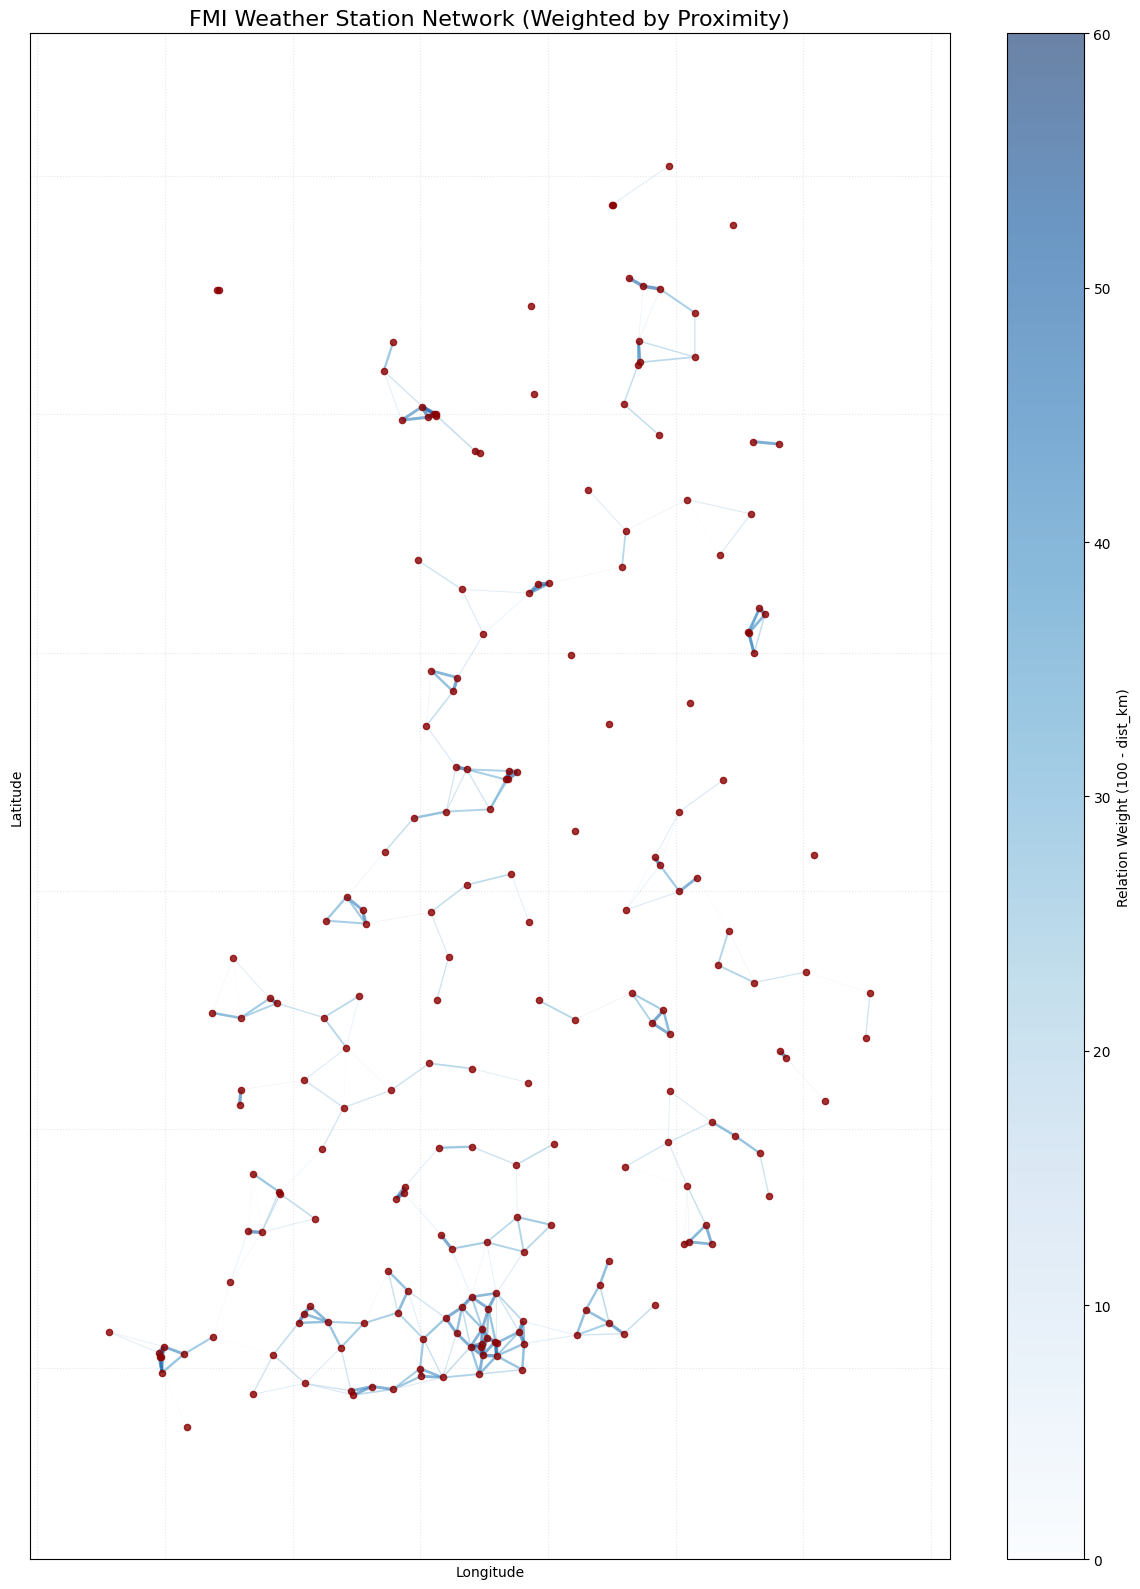

In [11]:
if 'G' in locals() and G.number_of_edges() > 0:
    plt.figure(figsize=(12, 16))
    pos = nx.get_node_attributes(G, 'pos')

    # Get weights for visual mapping
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    # Normalise widths for better display (scale 0.1 to 3.0)
    max_w = max(weights) if weights else 1
    widths = [(w / max_w) * 3.0 for w in weights]

    # Draw edges with weight-based color mapping
    edge_collection = nx.draw_networkx_edges(
        G, pos, 
        width=widths, 
        edge_color=weights, 
        edge_cmap=plt.cm.Blues, 
        edge_vmin=0, edge_vmax=60,
        alpha=0.6
    )

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=20, node_color='darkred', alpha=0.8)

    plt.colorbar(edge_collection, label='Relation Weight (100 - dist_km)')
    plt.title("FMI Weather Station Network (Weighted by Proximity)", fontsize=16)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Graph is empty or not found.")